# Random Forest for Financial Report

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
PRICE_DATA_PATH = (
    'CS-IDX30 version 3/'
    'pricehistory data/Finance/BBCA.JK_dataprice.xlsx'
)

FUNDAMENTAL_PATH   = 'BBCA_monthly_parsed.csv'

TEST_MONTHS        = 12
N_ESTIMATORS       = 200
RANDOM_STATE       = 42

RF_PREDICTIONS_OUT = 'rf_predictions.csv'
RF_MODEL_OUT       = 'rf_model.pkl'

In [3]:
def load_price_data(path):
    df = pd.read_excel(path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df = df.rename(columns = {'Date': 'ds', 'Close': 'y'})[['ds', 'y']]
    print(f"[Price]  {df['ds'].min().date()} to {df['ds'].max().date()}  ({len(df)} rows)")
    return df

df_price = load_price_data(PRICE_DATA_PATH)

[Price]  2017-07-31 to 2022-07-29  (1256 rows)


In [4]:
def load_fundamental_data(path):
    fund = pd.read_csv(path)
    fund['ds'] = pd.to_datetime(fund['ds'])
    fund = fund.sort_values('ds').reset_index(drop=True)
    print(f"[Fundamentals]  {len(fund)} monthly observations")
    print(f"  {fund['ds'].min().date()} to {fund['ds'].max().date()}")
    return fund

fund_m = load_fundamental_data(FUNDAMENTAL_PATH)

[Fundamentals]  106 monthly observations
  2015-03-31 to 2025-11-30


In [5]:
FEATURE_COLS = [
    'interest_income', 'interest_expense', 'net_profit',
    'personnel_expense', 'total_assets', 'total_loans',
    'current_accounts', 'savings_accounts', 'time_deposits'
]
TARGET_COL = 'target_return'

def build_monthly_dataset(fund_m, df_price):
    df = df_price[['ds', 'y']].copy().reset_index(drop=True)
    df['log_return'] = np.log(df['y'] / df['y'].shift(1))
    records = []
    months  = fund_m['ds'].tolist()
    for i, m_end in enumerate(months[:-1]):
        next_m_end = months[i + 1]
        mask     = (df['ds'] > m_end) & (df['ds'] <= next_m_end)
        log_rets = df['log_return'][mask].dropna()
        if log_rets.empty:
            continue
        row = fund_m.loc[fund_m['ds'] == m_end].iloc[0].to_dict()
        row['target_return'] = log_rets.mean()
        row['month_label']   = f"{m_end.year}-{m_end.month:02d}"
        records.append(row)
    df_out = pd.DataFrame(records).reset_index(drop=True)
    print(f"[Dataset]  {len(df_out)} labelled months")
    print(df_out[['ds', 'month_label', 'target_return']].to_string(index=False))
    return df_out

df_model = build_monthly_dataset(fund_m, df_price)

[Dataset]  51 labelled months
        ds month_label  target_return
2017-07-31     2017-07       0.000577
2017-08-31     2017-08       0.002278
2017-10-31     2017-10      -0.001041
2017-11-30     2017-11       0.003496
2017-12-31     2017-12       0.001608
2018-01-31     2018-01       0.000980
2018-02-28     2018-02       0.000245
2018-03-31     2018-03      -0.002157
2018-04-30     2018-04       0.001165
2018-05-31     2018-05      -0.002642
2018-06-30     2018-06       0.003659
2018-07-31     2018-07       0.002759
2018-08-31     2018-08      -0.001328
2018-09-30     2018-09      -0.000910
2018-10-31     2018-10       0.004393
2018-11-30     2018-11       0.000064
2018-12-31     2018-12       0.003493
2019-01-31     2019-01      -0.001076
2019-02-28     2019-02      -0.000043
2019-03-31     2019-03       0.002352
2019-04-30     2019-04       0.000526
2019-05-31     2019-05       0.001481
2019-06-30     2019-06       0.000386
2019-08-31     2019-08      -0.000235
2019-09-30     2019-

In [6]:
X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

tscv      = TimeSeriesSplit(n_splits=5)
rf        = RandomForestRegressor(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X, y, cv=tscv, scoring='neg_mean_absolute_error')
print(f"CV MAE (5-fold time-series): {-cv_scores.mean():.6f} +/- {cv_scores.std():.6f}")

X_train, X_test = X[:-TEST_MONTHS], X[-TEST_MONTHS:]
y_train, y_test = y[:-TEST_MONTHS], y[-TEST_MONTHS:]

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae     = mean_absolute_error(y_test, y_pred)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
dir_acc = np.mean(np.sign(y_test) == np.sign(y_pred)) * 100

print(f"Test MAE        : {mae:.6f}")
print(f"Test RMSE       : {rmse:.6f}")
print(f"Directional Acc : {dir_acc:.1f}%")

CV MAE (5-fold time-series): 0.002102 +/- 0.000499
Test MAE        : 0.001771
Test RMSE       : 0.002292
Directional Acc : 58.3%


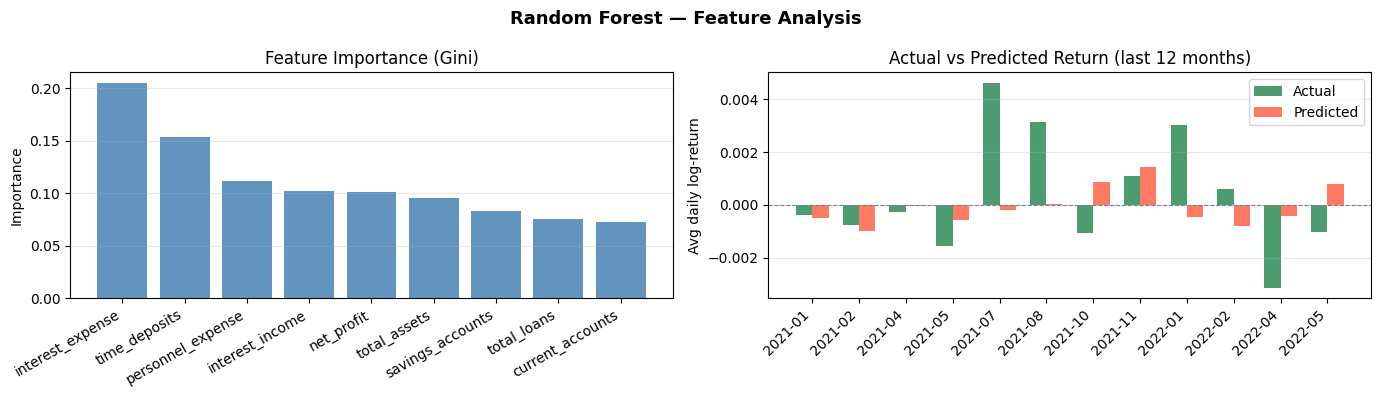

[Saved] rf_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Random Forest — Feature Analysis', fontsize=13, fontweight='bold')

importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
axes[0].bar(range(len(FEATURE_COLS)), importances[order], color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(FEATURE_COLS)))
axes[0].set_xticklabels([FEATURE_COLS[i] for i in order], rotation=30, ha='right')
axes[0].set_title('Feature Importance (Gini)')
axes[0].set_ylabel('Importance')
axes[0].grid(True, alpha=0.3, axis='y')

test_labels = df_model['month_label'].values[-TEST_MONTHS:]
x = np.arange(len(test_labels))
w = 0.35
axes[1].bar(x - w/2, y_test, w, label='Actual',    color='seagreen', alpha=0.85)
axes[1].bar(x + w/2, y_pred, w, label='Predicted', color='tomato',   alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(test_labels, rotation=45, ha='right')
axes[1].set_title(f'Actual vs Predicted Return (last {TEST_MONTHS} months)')
axes[1].set_ylabel('Avg daily log-return')
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] rf_analysis.png')

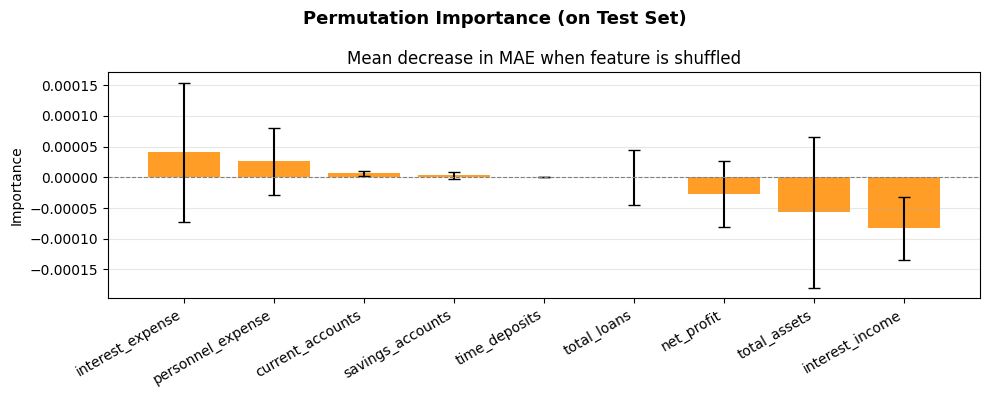

[Saved] rf_permutation_importance.png

Ranking:
  interest_expense          0.000040 +/- 0.000114
  personnel_expense         0.000026 +/- 0.000055
  current_accounts          0.000006 +/- 0.000004
  savings_accounts          0.000003 +/- 0.000005
  time_deposits             0.000000 +/- 0.000000
  total_loans               -0.000000 +/- 0.000045
  net_profit                -0.000027 +/- 0.000053
  total_assets              -0.000057 +/- 0.000123
  interest_income           -0.000083 +/- 0.000051


In [8]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats    = 30,
    random_state = RANDOM_STATE,
    scoring      = 'neg_mean_absolute_error'
)

perm_means = perm.importances_mean
perm_stds  = perm.importances_std
order_perm = np.argsort(perm_means)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Permutation Importance (on Test Set)', fontsize=13, fontweight='bold')

ax.bar(
    range(len(FEATURE_COLS)),
    perm_means[order_perm],
    yerr   = perm_stds[order_perm],
    color  = 'darkorange',
    alpha  = 0.85,
    capsize= 4
)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_xticklabels([FEATURE_COLS[i] for i in order_perm], rotation=30, ha='right')
ax.set_title('Mean decrease in MAE when feature is shuffled')
ax.set_ylabel('Importance')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rf_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] rf_permutation_importance.png')

print('\nRanking:')
for i in order_perm:
    print(f"  {FEATURE_COLS[i]:<25} {perm_means[i]:.6f} +/- {perm_stds[i]:.6f}")


In [9]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators'     : [100, 200, 300],
#     'max_depth'        : [None, 3, 5, 7, 10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features'     : ['sqrt', None, 0.5],
# }

# tscv_tune = TimeSeriesSplit(n_splits=5)

# search = GridSearchCV(
#     RandomForestRegressor(random_state=RANDOM_STATE),
#     param_grid = param_grid,
#     cv         = tscv_tune,
#     scoring    = 'neg_mean_absolute_error',
#     n_jobs     = -1,
#     verbose    = 1,
# )

# search.fit(X_train, y_train)

# print(f"\nBest params : {search.best_params_}")
# print(f"Best CV MAE : {-search.best_score_:.6f}")

# # Replace rf with tuned model — Cell 7 and 8 use this
# rf      = search.best_estimator_
# y_pred  = rf.predict(X_test)

# mae     = mean_absolute_error(y_test, y_pred)
# rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
# dir_acc = np.mean(np.sign(y_test) == np.sign(y_pred)) * 100

# print(f"\nTuned Test MAE        : {mae:.6f}")
# print(f"Tuned Test RMSE       : {rmse:.6f}")
# print(f"Tuned Directional Acc : {dir_acc:.1f}%")
